# TASK 5 — Content Rating & Genre Analysis

Task Requirements

Analyze rating categories , 
Identify the most common genres , 
Compare ratings across Movies and TV Shows , 
Create interactive/clear visualizations , 
Present audience insights.

In [1]:
%pip install seaborn
%matplotlib inline


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# loading the cleaned Netflix dataset

df = pd.read_csv("Netflix_Cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head(5)

Dataset loaded successfully!
Shape: (8790, 14)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_month_name,duration_value
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,September,90.0
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,September,1.0
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,September,1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,September,91.0
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,September,125.0


In [5]:
# checking rating categories

print("Rating Categories:")
print(df["rating"].unique())

Rating Categories:
<StringArray>
[   'PG-13',    'TV-MA',    'TV-PG',    'TV-14',    'TV-Y7',     'TV-Y',
       'PG',     'TV-G',        'R',        'G',    'NC-17',       'NR',
 'TV-Y7-FV',       'UR']
Length: 14, dtype: str


In [6]:
# counting each rating category

rating_counts = df["rating"].value_counts()

print("Netflix Rating Distribution:")
print(rating_counts)

Netflix Rating Distribution:
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


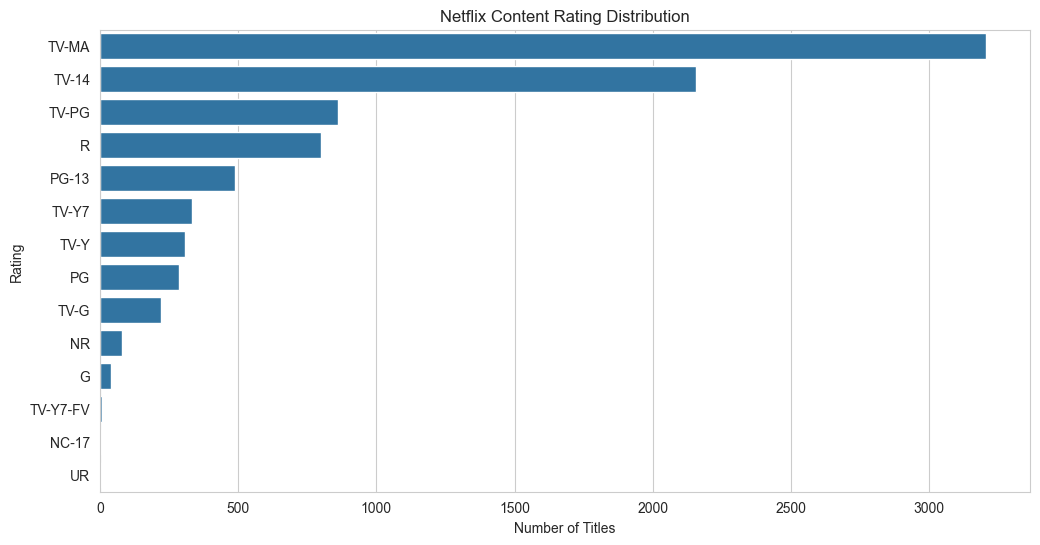

In [7]:
# visualizing rating distribution

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="rating",
    order=rating_counts.index
)

plt.title("Netflix Content Rating Distribution")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

In [8]:
# creating rating summary table

rating_summary = rating_counts.reset_index()

rating_summary.columns = [
    "Rating",
    "Number_of_Titles"
]

rating_summary


,Rating,Number_of_Titles
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


In [9]:
# checking genre information

print("Genre information:")
print(df["listed_in"].head(10))

Genre information:
0                                        Documentaries
1    Crime TV Shows, International TV Shows, TV Act...
2                   TV Dramas, TV Horror, TV Mysteries
3                   Children & Family Movies, Comedies
4     Dramas, Independent Movies, International Movies
5                         British TV Shows, Reality TV
6                                     Comedies, Dramas
7    Children & Family Movies, Comedies, Music & Mu...
8                         Dramas, International Movies
9           Children & Family Movies, Music & Musicals
Name: listed_in, dtype: str


In [10]:
# creating a copy of the dataset

genre_df = df.copy()

# splitting multiple genres

genre_df["listed_in"] = genre_df["listed_in"].str.split(",")

# creating separate row for each genre

genre_df = genre_df.explode("listed_in")

# removing extra spaces

genre_df["listed_in"] = genre_df["listed_in"].str.strip()

print("Genre data cleaned successfully!")

genre_df[["title", "listed_in"]].head(10)

Genre data cleaned successfully!


,title,listed_in
0,Dick Johnson Is Dead,Documentaries
1,Ganglands,Crime TV Shows
1,Ganglands,International TV Shows
1,Ganglands,TV Action & Adventure
2,Midnight Mass,TV Dramas
2,Midnight Mass,TV Horror
2,Midnight Mass,TV Mysteries
3,Confessions of an Invisible Girl,Children & Family Movies
3,Confessions of an Invisible Girl,Comedies
4,Sankofa,Dramas


In [11]:
# counting the number of titles in each genre

genre_counts = genre_df["listed_in"].value_counts()

print("Top 20 Netflix Genres:")
print(genre_counts.head(20))

Top 20 Netflix Genres:
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  573
Crime TV Shows               469
Kids' TV                     448
Docuseries                   394
Music & Musicals             375
Romantic TV Shows            370
Horror Movies                357
Stand-Up Comedy              343
Reality TV                   255
Name: count, dtype: int64


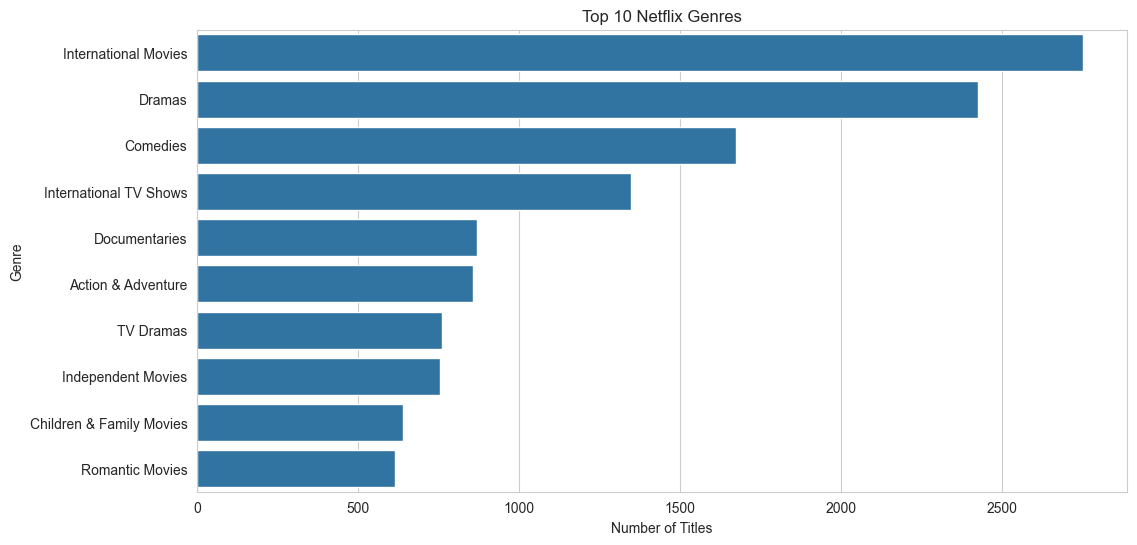

In [12]:
# selecting top 10 genres

top_10_genres = genre_counts.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_genres.values,
    y=top_10_genres.index
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [13]:
# creating genre summary table

genre_summary = genre_counts.reset_index()

genre_summary.columns = [
    "Genre",
    "Number_of_Titles"
]

genre_summary.head(20)

,Genre,Number_of_Titles
0,International Movies,2752
1,Dramas,2426
2,Comedies,1674
3,International TV Shows,1349
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,762
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


In [14]:
# creating rating and content type table

rating_type = (
    df.groupby(["rating", "type"])
    .size()
    .reset_index(name="Number_of_Titles")
)

rating_type.head(20)

,rating,type,Number_of_Titles
0,G,Movie,41
1,NC-17,Movie,3
2,NR,Movie,75
3,NR,Tv Show,4
4,PG,Movie,287
5,PG-13,Movie,490
6,R,Movie,797
7,R,Tv Show,2
8,TV-14,Movie,1427
9,TV-14,Tv Show,730


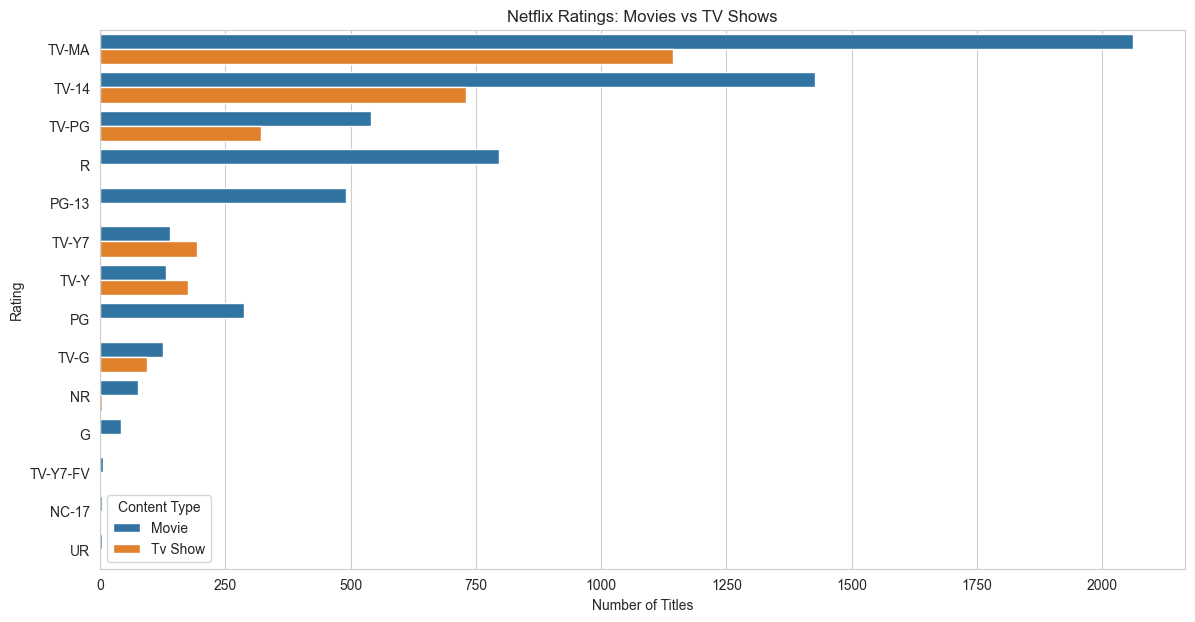

In [15]:
# comparing ratings across Movies and TV Shows

plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    y="rating",
    hue="type",
    order=rating_counts.index
)

plt.title("Netflix Ratings: Movies vs TV Shows")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.legend(title="Content Type")

plt.show()

In [16]:
# calculating rating percentages by content type

rating_type_percentage = (
    pd.crosstab(
        df["rating"],
        df["type"],
        normalize="columns"
    ) * 100
)

rating_type_percentage.round(2)

type,Movie,Tv Show
rating,,
G,0.67,0.00
NC-17,0.05,0.00
NR,1.22,0.15
PG,4.68,0.00
PG-13,8.00,0.00
R,13.01,0.08
TV-14,23.29,27.40
TV-G,2.06,3.53
TV-MA,33.66,42.91


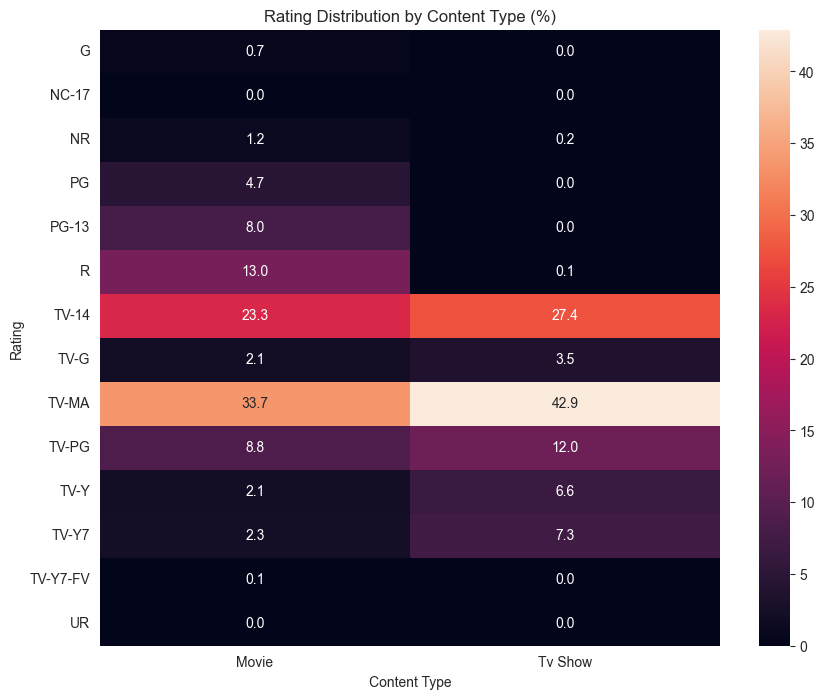

In [17]:
# creating a heatmap for rating distribution

plt.figure(figsize=(10, 8))

sns.heatmap(
    rating_type_percentage,
    annot=True,
    fmt=".1f"
)

plt.title("Rating Distribution by Content Type (%)")
plt.xlabel("Content Type")
plt.ylabel("Rating")

plt.show()

In [18]:
# finding the most common rating

most_common_rating = rating_counts.idxmax()
most_common_rating_count = rating_counts.max()

print("Most Common Rating:", most_common_rating)
print("Number of Titles:", most_common_rating_count)

Most Common Rating: TV-MA
Number of Titles: 3205


In [19]:
# finding the most common genre

most_common_genre = genre_counts.idxmax()
most_common_genre_count = genre_counts.max()

print("Most Common Genre:", most_common_genre)
print("Number of Titles:", most_common_genre_count)

Most Common Genre: International Movies
Number of Titles: 2752


In [20]:
# finding the most common movie rating

movie_ratings = (
    df[df["type"] == "Movie"]["rating"]
    .value_counts()
)

print("Most Common Movie Rating:")
print(movie_ratings.head(10))

Most Common Movie Rating:
rating
TV-MA    2062
TV-14    1427
R         797
TV-PG     540
PG-13     490
PG        287
TV-Y7     139
TV-Y      131
TV-G      126
NR         75
Name: count, dtype: int64


In [23]:
print(df["type"].unique())
print(df["type"].value_counts())

<StringArray>
['Movie', 'Tv Show']
Length: 2, dtype: str
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64


In [25]:
# cleaning the type column

df["type"] = df["type"].astype(str).str.strip()

print(df["type"].unique())
print(df["type"].value_counts())

<StringArray>
['Movie', 'Tv Show']
Length: 2, dtype: str
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64


In [27]:
# finding the most common TV Show rating

tv_ratings = (
    df[df["type"].str.lower() == "tv show"]["rating"]
    .value_counts()
)

print("Most Common TV Show Rating:")
print(tv_ratings.head(10))

Most Common TV Show Rating:
rating
TV-MA       1143
TV-14        730
TV-PG        321
TV-Y7        194
TV-Y         175
TV-G          94
NR             4
R              2
TV-Y7-FV       1
Name: count, dtype: int64


In [28]:
# identifying most common ratings

top_movie_rating = movie_ratings.idxmax()
top_movie_rating_count = movie_ratings.max()

top_tv_rating = tv_ratings.idxmax()
top_tv_rating_count = tv_ratings.max()

print("Most Common Movie Rating:")
print(top_movie_rating, "-", top_movie_rating_count)

print("\nMost Common TV Show Rating:")
print(top_tv_rating, "-", top_tv_rating_count)

Most Common Movie Rating:
TV-MA - 2062

Most Common TV Show Rating:
TV-MA - 1143


In [29]:
# generating audience insights

print("=" * 60)
print("           TASK 5 - AUDIENCE INSIGHTS")
print("=" * 60)

print(
    f"\n1. The most common Netflix rating is "
    f"{most_common_rating}."
)

print(
    f"   Number of titles: {most_common_rating_count}"
)

print(
    f"\n2. The most common Netflix genre is "
    f"{most_common_genre}."
)

print(
    f"   Number of titles: {most_common_genre_count}"
)

print(
    f"\n3. The most common Movie rating is "
    f"{top_movie_rating}."
)

print(
    f"4. The most common TV Show rating is "
    f"{top_tv_rating}."
)

print(
    "\n5. Rating analysis helps identify the primary "
    "audience segments targeted by Netflix."
)

print(
    "6. Genre analysis helps identify the types of "
    "content that are most widely represented."
)

print(
    "7. Comparing Movies and TV Shows reveals differences "
    "in their audience targeting."
)

           TASK 5 - AUDIENCE INSIGHTS

1. The most common Netflix rating is TV-MA.
   Number of titles: 3205

2. The most common Netflix genre is International Movies.
   Number of titles: 2752

3. The most common Movie rating is TV-MA.
4. The most common TV Show rating is TV-MA.

5. Rating analysis helps identify the primary audience segments targeted by Netflix.
6. Genre analysis helps identify the types of content that are most widely represented.
7. Comparing Movies and TV Shows reveals differences in their audience targeting.


In [30]:
# exporting rating analysis

rating_summary.to_csv(
    "Netflix_Rating_Analysis.csv",
    index=False
)

# exporting genre analysis

genre_summary.to_csv(
    "Netflix_Genre_Analysis.csv",
    index=False
)

# exporting rating vs content type analysis

rating_type.to_csv(
    "Netflix_Rating_Type_Analysis.csv",
    index=False
)

print("Task 5 analysis files exported successfully!")

print("\nFiles created:")
print("1. Netflix_Rating_Analysis.csv")
print("2. Netflix_Genre_Analysis.csv")
print("3. Netflix_Rating_Type_Analysis.csv")

Task 5 analysis files exported successfully!

Files created:
1. Netflix_Rating_Analysis.csv
2. Netflix_Genre_Analysis.csv
3. Netflix_Rating_Type_Analysis.csv
